# How a facet map is actually produced

The processing path of `scripts/73_map_inference.py`, shown as code and then **run** on one
tile: load the tile's whole Landsat archive span once, cut a causal `y-2..y` window per
target year, build a 100-step raw kNDVI curve for every pixel, fold it into the serpentine
image, attach the pixel's topography, run the five all-data seed checkpoints, back-transform,
and write a ten-band GeoTIFF.

The companion notebook, `10_map_inference_run.ipynb`, is the record of the production run —
what was measured, what broke, where it stands. This one is only the mechanism.

**What runs here and what does not.** Section 2 executes the real tile path, on one tile and
one year, so it finishes in a couple of minutes. It raises no cluster and writes no manifest.
Section 3 shows how the full 5,769-tile run is launched, **commented out**: it takes days,
and a run that hangs off a Jupyter kernel dies with the kernel — which is how the previous
attempt was lost.

In [1]:
import json
import re
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
pd.set_option("display.width", 120)
print(ROOT)

/home/jovyan/temp/Biodiversity_Chile


## 1. The code that actually runs

Shown from the modules rather than copied into cells: a notebook that pastes the
orchestration is a second copy that drifts, and the whole argument for
`src/biodiv/maptask.py` is that there is exactly one tile loop. `inspect.getsource` keeps
this section honest — if it disagrees with the code, it is because the code changed.

In [2]:
import inspect                                         # noqa: E402

from biodiv import maptask as mt                       # noqa: E402

import importlib.util                                # noqa: E402

_spec = importlib.util.spec_from_file_location("s73", ROOT / "scripts" / "73_map_inference.py")
s73 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(s73)


def show(obj, drop_doc=False):
    src = inspect.getsource(obj)
    if drop_doc:                    # the docstrings are the reasoning; keep them by default
        src = re.sub(r'"""(?:.|\n)*?"""\n\s*', "", src, count=1)
    print(src.rstrip())
    print("-" * 100)


print("### the load: one tile, whole archive span, on a THREAD pool")
show(mt.load_tile)

### the load: one tile, whole archive span, on a THREAD pool
def load_tile(dc, tile: dict, cfg: TileConfig):
    """The whole archive span for one tile, computed.

    The load is 96 % fixed cost -- ~1,800 COG headers rather than bytes (`logs/load_scaling.log`)
    -- so it is done once per tile for ``years[0]-2 .. years[-1]`` and every year is cut from
    it in memory, and it is computed on a *thread* pool. Inside a dask worker the scheduler
    has to be named explicitly: the default would hand the graph back to the distributed
    scheduler that is already running this task.

    Threads are not free scaling, and the measurement says so (`logs/thread_scaling.log`,
    10 km tile, 1,812 dates): 1 thread 1,892 s, 4 threads 643 s (2.9x), 8 threads 562 s
    (3.4x). It flattens because GDAL's COG header parsing holds the GIL -- the same load on
    8 dask *processes* takes 304 s. So threads inside a tile are worth about 3x and no more,
    and the parallelism that actually pays is one 

`load_tile` is where the run died the first time at scale. `cfg.load_client` came from
`--workers`, whose default is 4, so `da.compute()` ran with no explicit scheduler — and
inside a dask worker that hands the graph back to the distributed scheduler already running
the task. Every tile returned
`FutureCancelledError ... scheduler-connection-lost`. The gateway path now forces
`load_client=False` so no command line can reintroduce it.

In [3]:
print("### the tile loop: curves, mask, ensemble, GeoTIFF, one row per year")
show(mt.run_tile)

### the tile loop: curves, mask, ensemble, GeoTIFF, one row per year
def run_tile(dc, tile: dict, cfg: TileConfig, ens, resid, y_train, perm,
             skip_years: frozenset[int] = frozenset()) -> list[dict]:
    """One tile, every requested year, written out. Returns the manifest rows."""
    todo = [y for y in cfg.years if y not in skip_years]
    if not todo:
        return []
    t0 = time.time()
    da = load_tile(dc, tile, cfg)
    if da is None:
        return [dict(tile_id=tile["tile_id"], year=y, status="no_data") for y in todo]
    t_load = time.time() - t0

    times = da.time.values
    ny, nx = da.sizes["y"], da.sizes["x"]
    obs = da.values.reshape(len(times), ny * nx)
    template = da.isel(time=0)
    lon_c, lat_c = to_lonlat(np.array([(tile["xmin"] + tile["xmax"]) / 2]),
                             np.array([(tile["ymin"] + tile["ymax"]) / 2]))
    terrain = mi.load_terrain(dc, template, float(lat_c[0]), resolution=cfg.resolution)
    topo = {k: v.reshape(-1) for 

In [4]:
print("### the worker entry point, and the per-process state it caches")
show(mt.run_tile_remote)
show(mt.worker_state)

### the worker entry point, and the per-process state it caches
def run_tile_remote(tile: dict, payload: Payload, cfg: TileConfig,
                    skip_years: tuple[int, ...] = ()) -> list[dict]:
    """Dask entry point: one whole tile on a gateway worker.

    Failures are returned, not raised. One tile that cannot be read -- a transient S3 error,
    a gap in the archive -- must not take down a run of thousands, and the manifest is the
    place where that is recorded and where ``--resume`` reads it back.
    """
    try:
        st = worker_state(payload, cfg)
        return run_tile(st["dc"], tile, cfg, st["ens"], payload.resid, payload.y_train,
                        st["perm"], frozenset(skip_years))
    except Exception as e:                                          # noqa: BLE001
        return [dict(tile_id=tile["tile_id"], year=y, status="error",
                     error=f"{type(e).__name__}: {str(e)[:200]}")
                for y in cfg.years if y not in set(skip_year

Two things in `worker_state` are the difference between a working worker and 5,769 failed
tiles: the ensemble is built once per process and keyed on the checkpoint bytes (rebuilding
five torch models per tile would be pure waste over hundreds of tiles), and
`configure_s3_access` is called again on the worker — not redundantly, because a worker that
joined after the client configured the cluster would otherwise read `usgs-landsat` unsigned
and get `AccessDenied` on every scene.

In [5]:
print("### raising the cluster, shipping the code, submitting the tiles")
show(s73.fan_out_gateway)

### raising the cluster, shipping the code, submitting the tiles
def fan_out_gateway(args, tiles: pd.DataFrame, cfg, ckpts, resid, y_train,
                    man_path: Path, done: set) -> None:
    """Run whole tiles on dask-gateway workers, one tile per task.

    WHY THE WHOLE TILE AND NOT JUST THE LOAD. The obvious use of a cluster here is to
    parallelise the Landsat read, and that is what an earlier version did. It is the wrong
    lever, and by a wide margin: with 10 target years a tile spends ~300 s loading and
    ~1,100 s in the CNN, so a cluster that only loads attacks 21 % of the work and leaves
    its workers idle for the other 79 % -- exactly the pattern the pilot already showed
    (`docs/21` section 6). Sending the tile itself makes every worker do all of it.

    WHAT HAD TO MOVE. A gateway worker sees no home directory (measured,
    `logs/gw_probe.log`), so: the `biodiv` package is uploaded as a zip, the five
    checkpoints ride along as bytes in a broadcast pay

In [6]:
print("### what gets shipped, and how the manifest stays resumable")
show(s73.package_biodiv)
show(s73.resume_done)

### what gets shipped, and how the manifest stays resumable
def package_biodiv() -> Path:
    """Zip `src/biodiv` for `Client.upload_file`, which puts it on the workers' sys.path.

    Built fresh on every run rather than kept as an artefact: the whole point of shipping
    the package is that the workers run the same code as the gate, and a stale zip is
    exactly the way that stops being true.
    """
    import zipfile
    src = ROOT / "src" / "biodiv"
    zp = Path(tempfile.gettempdir()) / "biodiv_worker.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for f in sorted(src.rglob("*.py")):
            z.write(f, str(Path("biodiv") / f.relative_to(src)))
        # `mapinfer.load_terrain` reads `terrain()` out of scripts/03 by path, to keep that
        # script the single source of the topographic derivatives. A worker has no repo to
        # read it from, and a by-path load cannot see inside a zip, so the same file rides
        # along as an importable mo

## 2. One tile, end to end

The same `mt.run_tile` the workers call, on the Cauquenes pilot tile, for a single year so
the archive span is 2018–2020 and this finishes in a couple of minutes. No cluster is raised:
a second gateway cluster is what cost the production run its scheduler
(`10_map_inference_run.ipynb` §5), and the point
here is the tile path, not the fan-out.

In [7]:
import os                                              # noqa: E402
import tempfile                                        # noqa: E402

# `training_targets` reads the unified target tables; both are needed for the range clipping
os.environ["BIODIV_UNIFIED"] = "1"
os.environ["BIODIV_CURVES"] = "_raw100"

import datacube                                        # noqa: E402
from datacube.utils.aws import configure_s3_access     # noqa: E402

from biodiv import mapinfer as mi                      # noqa: E402

# Not optional and not idempotent-by-luck: `usgs-landsat` is requester-pays, and without this
# every scene read comes back RasterioIOError('AccessDenied'). It has to happen before the
# Datacube is built -- the same boot order `scripts/73` and `scripts/35` follow.
configure_s3_access(aws_unsigned=False, requester_pays=True)

CKPT = ROOT / ("results/models_unified_topofix/C2D02_serpentine_kndvi_raw100_pg-all_unified_"
               "maekndvi_m06_ctr_FINAL_alldata/final")
OOF = ROOT / ("results/models_unified_topofix/C2D02_serpentine_kndvi_raw100_pg-all_unified_"
              "maekndvi_m06_ctr/kfold5_block20_unified/oof_predictions.csv")

ens = mi.FacetEnsemble(sorted(CKPT.glob("model_seed*.pt")))
resid = mi.oof_residuals_scaled(OOF, ens.members[0].scaler, ens.targets)
y_train = mi.training_targets(ROOT / "data" / "derived", ens.targets)
perm = mi.serpentine_perm(mi.NGS)
print(f"{len(ens.members)} seeds | targets {ens.targets}")
print(f"context ({len(ens.context_columns)}): {ens.context_columns}")
print(f"smearing residuals usable per target: {np.isfinite(resid).sum(axis=0).tolist()}")

/env/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/env/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


5 seeds | targets ['lcbd_count_sorensen', 'pd_inext_q0', 'pd_inext_q1', 'pd_inext_q2', 'td_inext_q0', 'td_inext_q1', 'td_inext_q2']
context (13): ['topo_elevation', 'topo_slope', 'topo_northness', 'topo_eastness', 'topo_heat_load', 'topo_tpi', 'topo_tri', 'topo_curvature', 'topo_topo_flat', 'area_log10', 'area_stratum_counts', 'area_stratum_presence', 'area_stratum_basal']
smearing residuals usable per target: [2499, 888, 888, 888, 895, 895, 895]


In [8]:
dc = datacube.Datacube(app="nb10-one-tile")
out = Path(tempfile.mkdtemp(prefix="nb10_"))

TILE_M = 9990
tile = dict(tile_id="t18_600", xmin=18 * TILE_M, ymin=600 * TILE_M,
            xmax=19 * TILE_M, ymax=601 * TILE_M)
cfg = mt.TileConfig(
    years=(2020,), dest=str(out), resolution=30, area_m2=900.0, stratum="basal",
    mask="mapbiomas", batch=8192, load_threads=4, load_client=False, torch_threads=0,
    tags=dict(tag="notebook_10_demo", years="2020-2020", area_m2=900.0, stratum="basal",
              smearing="oof", clip=True,
              caveat=("predicted values are conditional means and under-disperse the upper "
                      "tail; use as a relative surface")))

rows = mt.run_tile(dc, tile, cfg, ens, resid, y_train, perm)
if rows and rows[0].get("status") == "ok":
    display(pd.DataFrame(rows)[["tile_id", "year", "status", "n_px", "n_native", "n_pred",
                                "n_dates_window", "seconds", "load_seconds"]])
else:
    # Say which tile and why, instead of failing three cells later on a missing variable
    raise RuntimeError(f"the demo tile did not produce a raster: {rows}")

/env/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


,tile_id,year,status,n_px,n_native,n_pred,n_dates_window,seconds,load_seconds
0,t18_600,2020,ok,110889,38934,38934,238,18.6,88.8


`n_pred` below `n_native` would mean pixels that are native but have no complete 100-step
curve; here they coincide. `load_seconds` is small only because the span is three years —
the production tiles carry 1998–2026 and pay ~1,100 s.

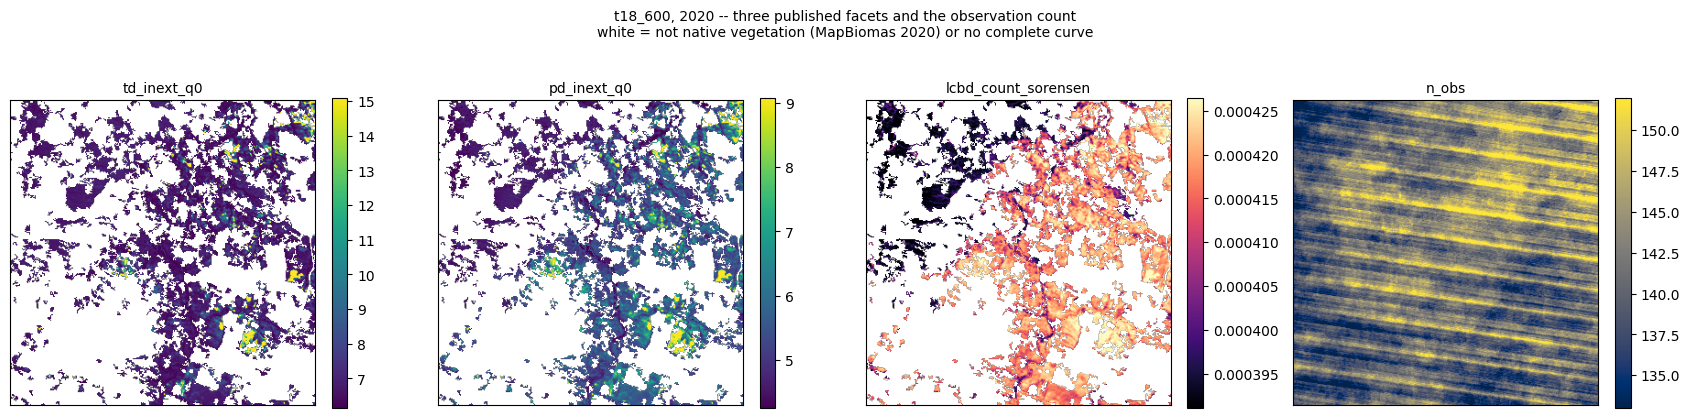

In [9]:
import matplotlib.pyplot as plt                        # noqa: E402
import rasterio                                        # noqa: E402

tif = Path(rows[0]["file"])
with rasterio.open(tif) as src:
    bands = {n: src.read(i) for i, n in enumerate(src.descriptions, 1)}
    tags = src.tags()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, name, cmap in zip(axes, ["td_inext_q0", "pd_inext_q0", "lcbd_count_sorensen", "n_obs"],
                          ["viridis", "viridis", "magma", "cividis"]):
    a = bands[name]
    finite = a[np.isfinite(a)]
    im = ax.imshow(a, cmap=cmap,
                   vmin=np.percentile(finite, 2) if finite.size else None,
                   vmax=np.percentile(finite, 98) if finite.size else None)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"t18_600, {tags['year']} -- three published facets and the observation count\n"
             f"white = not native vegetation (MapBiomas {tags['map_year']}) or no complete curve",
             fontsize=10)
fig.tight_layout()
plt.show()

In [10]:
# The three publishable facets against the plot range they were trained on: the maps
# under-disperse the upper tail by construction (docs/21 section 6), and this is where that
# shows rather than a caveat to take on trust.
tr = pd.DataFrame(y_train, columns=ens.targets)
summary = []
for t in ("td_inext_q0", "pd_inext_q0", "lcbd_count_sorensen"):
    a = bands[t][np.isfinite(bands[t])]
    summary.append(dict(facet=t, map_median=np.median(a), map_max=a.max(),
                        train_median=tr[t].median(), train_max=tr[t].max()))
display(pd.DataFrame(summary).set_index("facet").round(3))
print("The map maximum sitting well below the training maximum is the compression, not a bug.")

,map_median,map_max,train_median,train_max
facet,,,,
td_inext_q0,6.760,43.498001,7.219,83.981
pd_inext_q0,5.275,14.547000,4.791,26.564
lcbd_count_sorensen,0.000,0.000000,0.000,0.000


The map maximum sitting well below the training maximum is the compression, not a bug.


## 3. Is dask actually parallelising the load? Measured on this tile

`load_tile` passes `dask_chunks={"time": 1}` whenever `load_threads > 0`, so the load *is* a
lazy dask graph, one chunk per acquisition date. What the gateway path changes is not the
chunking but **which scheduler executes it**: an in-process thread pool rather than the
distributed scheduler. There are two layers of parallelism and they are easy to conflate:

| layer | granularity | who runs it |
|---|---|---|
| distributed | one whole tile = one task | `dask.distributed`, 20 tiles at a time in production |
| threaded | the `{"time": 1}` chunks of that one tile | a local pool, 2–4 threads |

Only `--load-threads 0` with `--workers 0` gives `dask_chunks=None` and a plain synchronous
read. The cell below runs the same tile under each setting and times it, so the claim is a
table rather than an assertion.

Two caveats on reading these numbers. The demo span is three years (~200 dates), not the
29 the production tiles carry, so the absolute seconds are much smaller than the ~1,100 s a
real tile pays — the *ratios* are the point. And the pod is running 14 tile-processes while
this executes, so every row here is measured under load and is pessimistic.

In [11]:
import time                                            # noqa: E402
from dataclasses import replace                        # noqa: E402

timings = []
for lt in (0, 1, 2, 4, 8):
    probe = replace(cfg, load_threads=lt)
    t0 = time.time()
    da = mt.load_tile(dc, tile, probe)
    dt = time.time() - t0
    timings.append(dict(load_threads=lt,
                        dask_chunks="None" if lt == 0 else "{'time': 1}",
                        scheduler="synchronous read" if lt == 0 else f"threads, {lt} workers",
                        dates=int(da.sizes["time"]),
                        px=int(da.sizes["y"]) * int(da.sizes["x"]),
                        seconds=round(dt, 1)))
    print(timings[-1], flush=True)
    del da

t = pd.DataFrame(timings).set_index("load_threads")
t["vs sync"] = (t.seconds.iloc[0] / t.seconds).round(2).astype(str) + "x"
display(t)

{'load_threads': 0, 'dask_chunks': 'None', 'scheduler': 'synchronous read', 'dates': 238, 'px': 110889, 'seconds': 211.3}


{'load_threads': 1, 'dask_chunks': "{'time': 1}", 'scheduler': 'threads, 1 workers', 'dates': 238, 'px': 110889, 'seconds': 224.0}


{'load_threads': 2, 'dask_chunks': "{'time': 1}", 'scheduler': 'threads, 2 workers', 'dates': 238, 'px': 110889, 'seconds': 127.4}


{'load_threads': 4, 'dask_chunks': "{'time': 1}", 'scheduler': 'threads, 4 workers', 'dates': 238, 'px': 110889, 'seconds': 86.6}


{'load_threads': 8, 'dask_chunks': "{'time': 1}", 'scheduler': 'threads, 8 workers', 'dates': 238, 'px': 110889, 'seconds': 83.1}


,dask_chunks,scheduler,dates,px,seconds,vs sync
load_threads,,,,,,
0,None,synchronous read,238,110889,211.3,1.0x
1,{'time': 1},"threads, 1 workers",238,110889,224.0,0.94x
2,{'time': 1},"threads, 2 workers",238,110889,127.4,1.66x
4,{'time': 1},"threads, 4 workers",238,110889,86.6,2.44x
8,{'time': 1},"threads, 8 workers",238,110889,83.1,2.54x


The row at `load_threads=0` is the one that answers the question: it is the same load with
dask switched off entirely, and the gap to the threaded rows is dask's contribution. The gap
between 4 and 8 is the GIL — GDAL parses the COG headers holding it, which is why production
uses 2 threads inside a gateway worker running four tiles and 4 inside a pod process running
one, rather than the 8 or 16 that would look natural.

## 4. How the full run is launched

Not from here. The commands below are the ones that produced the run in
`10_map_inference_run.ipynb`, kept as comments so this notebook cannot start days of compute
by being run top to bottom.

Three things about them are decisions, not defaults:

* **`setsid`**, because the first attempt at this run was a child of the terminal session and
  died with it, leaving nothing — not even a manifest to resume from.
* **the split**, because the allocation grants ~5 worker pods per cluster and the pod has 36
  cores of its own: neither side alone is the machine. Interleaved 3:2 rather than blocked,
  since tiles differ tenfold in archive density and contiguous blocks would hand one side all
  the cheap ones.
* **`--workers 0`**, because its default of 4 makes each worker push its load back to the
  scheduler that is running it, which killed the first full-scale attempt outright.

In [12]:
# ---- prepare the tile lists (results/figures/tiles_native_10km_run.csv is the 5,769 tiles
#      that survive the < 20 native-pixel filter; see notebook 10 section 3) --------------
#
# import pandas as pd
# t = pd.read_csv("results/figures/tiles_native_10km_run.csv")
# i = t.index % 5
# t[i < 3].to_csv("results/figures/tiles_run_gateway.csv", index=False)   # 3,462 tiles
# t[i >= 3].to_csv("results/figures/tiles_run_pod.csv", index=False)      # 2,307 tiles
#
# ---- the gateway half: 5 workers x 8 cores, 4 tiles each ------------------------------
#      2 load threads and 2 torch threads per tile, not 4 and 8: four tiles share one
#      process and therefore one GIL, and the load is what the GIL blocks.
#
# B=s3://easido-prod-user-scratch/$(python -c \
#     "import boto3;print(boto3.client('sts').get_caller_identity()['UserId'])")/biodiv
# CK=results/models_unified_topofix/C2D02_serpentine_kndvi_raw100_pg-all_unified_maekndvi_m06_ctr_FINAL_alldata/final
# OOF=results/models_unified_topofix/C2D02_serpentine_kndvi_raw100_pg-all_unified_maekndvi_m06_ctr/kfold5_block20_unified/oof_predictions.csv
#
# setsid nohup env BIODIV_UNIFIED=1 BIODIV_CURVES=_raw100 python -u scripts/73_map_inference.py \
#     --tiles-file results/figures/tiles_run_gateway.csv --years 2000-2026 \
#     --area-m2 900 --stratum basal --mask mapbiomas \
#     --ckpt-dir "$CK" --oof-csv "$OOF" \
#     --gw-workers 5 --worker-cores 8 --worker-memory 28 --worker-threads 4 \
#     --load-threads 2 --torch-threads 2 --workers 0 \
#     --dest "$B/maps/chile_30m_2000_2026" --mapbiomas-dir "$B/MapBiomas" \
#     --out results/maps --tag chile_gw --resume > logs/chile_gw.log 2>&1 &
#
# ---- the pod half: 14 tile-processes on 36 cores --------------------------------------
#      real processes, so no shared GIL: 4 load threads each and one torch thread, which is
#      ~5.6x more core-efficient than one many-threaded process. Memory is the binding
#      limit, not cores -- a tile load peaks at 2.4 GB.
#
# setsid nohup env BIODIV_UNIFIED=1 BIODIV_CURVES=_raw100 python -u scripts/73_map_inference.py \
#     --tiles-file results/figures/tiles_run_pod.csv --years 2000-2026 \
#     --area-m2 900 --stratum basal --mask mapbiomas \
#     --ckpt-dir "$CK" --oof-csv "$OOF" \
#     --jobs 14 --workers 0 --load-threads 4 --torch-threads 1 \
#     --dest "$B/maps/chile_30m_2000_2026" --mapbiomas-dir "$B/MapBiomas" \
#     --out results/maps --tag chile_pod --resume > logs/chile_pod.log 2>&1 &
#
# ---- mopping up ----------------------------------------------------------------------
#      --resume skips only rows with status "ok", so failures and no_data are retried. When
#      one half finishes, relaunch it against the FULL list and it picks up whatever the
#      other has not reached.

Before any of this may run at all, the gate: `scripts/74_check_map_consistency.py` has to
report ALL PASS. It checks, over the 3,102 training plots, that the map path reproduces the
training path's context, image and model output exactly, and that the target scaler closes
its round trip. No maps are produced if it fails — and that gate is the reason the tile loop
lives in `src/biodiv/maptask.py` rather than in the script, so that the code it checked is
the code the workers run.

```bash
BIODIV_UNIFIED=1 BIODIV_CURVES=_raw100 python scripts/74_check_map_consistency.py \
    --oof-csv "$OOF"
```